# Copula (dependency structure)

A copula separates *what each series looks like* (its marginal distribution) from *how the series move together* (their dependence). `CopulaGenerator` imposes a target correlation structure across channels while leaving each channel's marginal free — the right tool when the joint dependence matters more than any single series' dynamics.

::: {.callout-note}
## The model

$$z \sim \mathcal{N}(0, R), \qquad u_i = \Phi(z_i), \qquad x_i = F_i^{-1}(u_i)$$

A copula (`copula_type="gaussian"` or `"t"`) couples the channels through a `correlation_matrix`, then maps each channel back to its marginal. A t-copula adds tail dependence — extremes that co-occur — which a Gaussian copula misses.
:::

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import CopulaGenerator

## 1. Gaussian copula with correlated normal variables

Generate three correlated variables with specified pairwise correlations using a Gaussian copula.

In [ ]:
corr_matrix = np.array([[1.0, 0.8, 0.6], [0.8, 1.0, 0.7], [0.6, 0.7, 1.0]])

params_gaussian = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "copula_type": "gaussian",
    "correlation_matrix": corr_matrix,
    "marginal_distributions": [
        {"type": "normal", "loc": 100.0, "scale": 10.0},
        {"type": "normal", "loc": 50.0, "scale": 5.0},
        {"type": "normal", "loc": 200.0, "scale": 20.0},
    ],
    "seed": 42,
}

gen_gaussian = CopulaGenerator(engine="polars", **params_gaussian)
df_gaussian = gen_gaussian.generate(n_series=3)

print(f"Generated {len(df_gaussian)} observations with 3 correlated variables")
df_gaussian.head(10)

Generated 600 observations with 3 correlated variables


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,95.378555
"""0""",2000-01-02 00:00:00,81.197776
"""0""",2000-01-03 00:00:00,97.662273
"""0""",2000-01-04 00:00:00,112.804514
"""0""",2000-01-05 00:00:00,104.679034
"""0""",2000-01-06 00:00:00,106.63344
"""0""",2000-01-07 00:00:00,91.473154
"""0""",2000-01-08 00:00:00,110.159648
"""0""",2000-01-09 00:00:00,103.90346


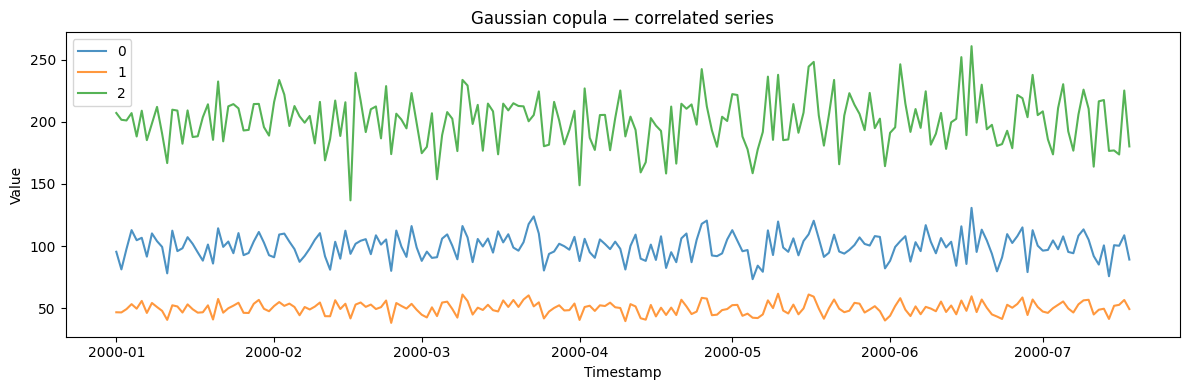

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_gaussian["unique_id"].unique().to_list():
    series = df_gaussian.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Gaussian copula — correlated series")
ax.legend()
plt.tight_layout()
plt.show()

### Verify correlations

Check that the empirical correlations match the specified correlation matrix.

In [ ]:
df_wide = df_gaussian.pivot(on="unique_id", index="ds", values="y")
series_cols = sorted([col for col in df_wide.columns if col != "ds"])

if len(series_cols) >= 3:
    corr_0_1 = np.corrcoef(
        df_wide[series_cols[0]].to_numpy(), df_wide[series_cols[1]].to_numpy()
    )[0, 1]
    corr_0_2 = np.corrcoef(
        df_wide[series_cols[0]].to_numpy(), df_wide[series_cols[2]].to_numpy()
    )[0, 1]
    corr_1_2 = np.corrcoef(
        df_wide[series_cols[1]].to_numpy(), df_wide[series_cols[2]].to_numpy()
    )[0, 1]

    print(f"Correlations (compared to specified):")
    print(f"  0 vs 1: {corr_0_1:.3f} (specified: 0.800)")
    print(f"  0 vs 2: {corr_0_2:.3f} (specified: 0.600)")
    print(f"  1 vs 2: {corr_1_2:.3f} (specified: 0.700)")

Correlations (compared to specified):
  0 vs 1: 0.809 (specified: 0.800)
  0 vs 2: 0.627 (specified: 0.600)
  1 vs 2: 0.745 (specified: 0.700)


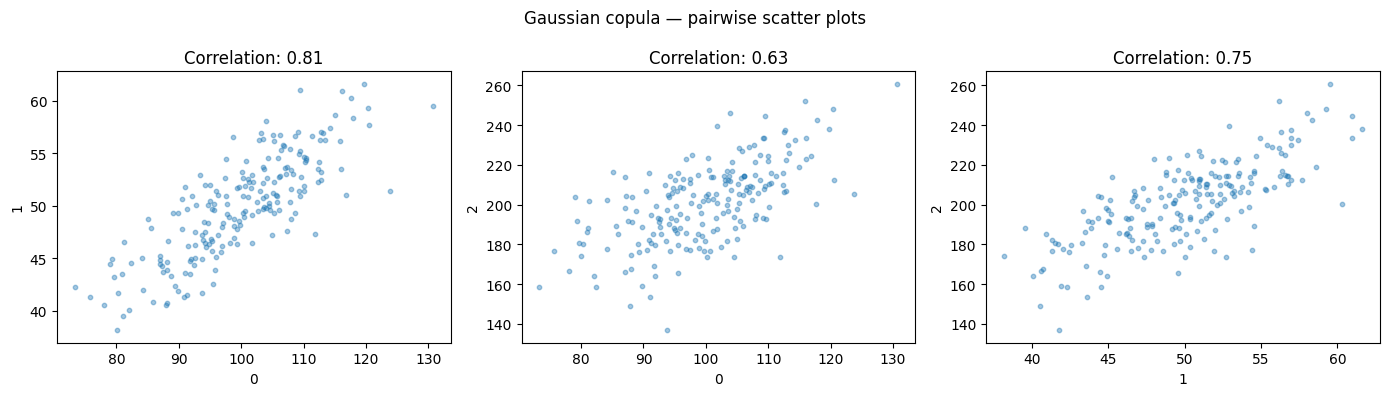

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols = sorted([c for c in df_wide.columns if c != "ds"])
pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(df_wide[cols[i]].to_list(), df_wide[cols[j]].to_list(), alpha=0.4, s=10)
    ax.set_xlabel(cols[i])
    ax.set_ylabel(cols[j])
    corr_val = np.corrcoef(df_wide[cols[i]].to_numpy(), df_wide[cols[j]].to_numpy())[0, 1]
    ax.set_title(f"Correlation: {corr_val:.2f}")
plt.suptitle("Gaussian copula — pairwise scatter plots")
plt.tight_layout()
plt.show()

## 2. t-copula with heavy tail dependence

A t-copula with the same correlation as a Gaussian copula makes joint extremes more likely: every time step, all channels share one chi-square variance-mixing draw, so large deviations tend to arrive together. That shared mixing also means a t-copula exhibits some dependence even at zero nominal correlation — always pass an explicit `correlation_matrix` so the dependence you observe is the dependence you configured.

Below, both copulas use the same 0.7 correlation and standard-normal marginals. Correlation alone cannot tell them apart; the joint tails can: we measure how often one channel sits in its worst (or best) 5% of values *given* that the other one does.

In [ ]:
corr_pair = np.array([[1.0, 0.7], [0.7, 1.0]])

common_params = {
    "min_length": 2000,
    "max_length": 2000,
    "freq": "D",
    "correlation_matrix": corr_pair,
    "marginal_distributions": [
        {"type": "normal", "loc": 0.0, "scale": 1.0},
        {"type": "normal", "loc": 0.0, "scale": 1.0},
    ],
    "seed": 123,
}

gen_gauss_pair = CopulaGenerator(
    engine="polars", copula_type="gaussian", **common_params
)
gen_t = CopulaGenerator(engine="polars", copula_type="t", df=3.0, **common_params)

wide = {}
for name, gen in [("gaussian", gen_gauss_pair), ("t", gen_t)]:
    df_pair = gen.generate(n_series=2)
    w = df_pair.pivot(on="unique_id", index="ds", values="y")
    cols = sorted(c for c in w.columns if c != "ds")
    wide[name] = (w[cols[0]].to_numpy(), w[cols[1]].to_numpy())

q = 0.05
print(f"Same specified correlation (0.7), joint {q:.0%}-tail behavior:\n")
for name, (x, y) in wide.items():
    pearson = np.corrcoef(x, y)[0, 1]
    lo = np.mean((x <= np.quantile(x, q)) & (y <= np.quantile(y, q)))
    hi = np.mean((x >= np.quantile(x, 1 - q)) & (y >= np.quantile(y, 1 - q)))
    cond = (lo + hi) / (2 * q)
    print(
        f"  {name:8s} copula: correlation {pearson:.2f}, "
        f"P(other channel also in its {q:.0%} tail) = {cond:.0%}"
    )
print(f"\n  independent channels would give {q:.0%}")

Same specified correlation (0.7), joint 5%-tail behavior:

  gaussian copula: correlation 0.70, P(other channel also in its 5% tail) = 39%
  t        copula: correlation 0.70, P(other channel also in its 5% tail) = 51%

  independent channels would give 5%


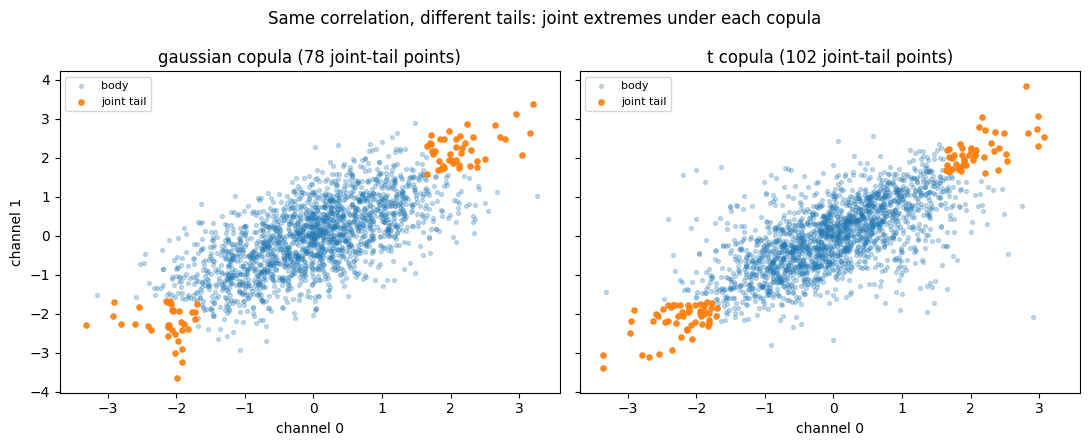

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, (name, (x, y)) in zip(axes, wide.items()):
    lo_x, lo_y = np.quantile(x, q), np.quantile(y, q)
    hi_x, hi_y = np.quantile(x, 1 - q), np.quantile(y, 1 - q)
    joint = ((x <= lo_x) & (y <= lo_y)) | ((x >= hi_x) & (y >= hi_y))
    ax.scatter(x[~joint], y[~joint], alpha=0.25, s=8, label="body")
    ax.scatter(x[joint], y[joint], alpha=0.9, s=14, label="joint tail")
    ax.set_title(f"{name} copula ({joint.sum()} joint-tail points)")
    ax.set_xlabel("channel 0")
    ax.legend(fontsize=8)
axes[0].set_ylabel("channel 1")
plt.suptitle("Same correlation, different tails: joint extremes under each copula")
plt.tight_layout()
plt.show()

## 3. Gaussian copula with mixed marginal distributions

Copulas decouple the dependency structure from the marginals, allowing different distribution types for each variable.

In [ ]:
params_mixed = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "copula_type": "gaussian",
    "marginal_distributions": [
        {"type": "normal", "loc": 100.0, "scale": 15.0},
        {"type": "lognormal", "mean": 4.0, "sigma": 0.3},
        {"type": "gamma", "shape": 2.0, "scale": 10.0},
        {"type": "uniform", "low": 0.0, "high": 100.0},
    ],
    "seed": 456,
}

gen_mixed = CopulaGenerator(engine="polars", **params_mixed)
df_mixed = gen_mixed.generate(n_series=4)

print(f"Generated {len(df_mixed)} observations with mixed marginals")

stats = df_mixed.group_by("unique_id").agg(
    pl.col("y").mean().alias("mean"), pl.col("y").std().alias("std")
)
stats.sort("unique_id")

Generated 800 observations with mixed marginals


unique_id,mean,std
cat,f64,f64
"""0""",100.361521,15.150987
"""1""",56.092974,16.038571
"""2""",20.491118,15.704863
"""3""",49.569035,28.428938


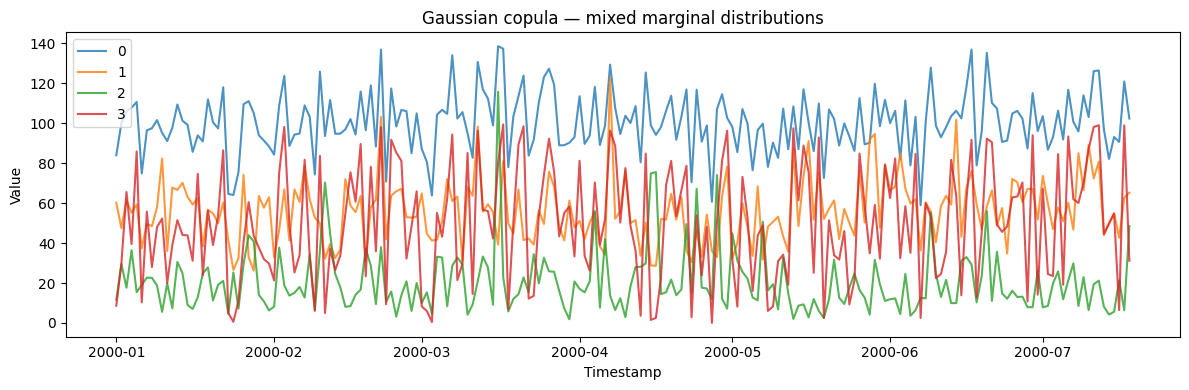

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_mixed["unique_id"].unique().to_list():
    series = df_mixed.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Gaussian copula — mixed marginal distributions")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Generating multiple correlated series

Generate multiple independent draws of correlated multivariate series.

In [ ]:
params_multi = {
    "min_length": 100,
    "max_length": 100,
    "freq": "h",
    "copula_type": "gaussian",
    "seed": 789,
}

gen_multi = CopulaGenerator(engine="polars", **params_multi)
df_multi = gen_multi.generate(n_series=3)

print(f"Generated 3 multivariate series")
print(f"Total rows: {len(df_multi)}")
print(f"Unique series IDs: {df_multi['unique_id'].unique().to_list()}")

df_multi.filter(pl.col("unique_id") == "0").head(5)

Generated 3 multivariate series
Total rows: 300
Unique series IDs: ['0', '1', '2']


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-1.177967
"""0""",2000-01-01 01:00:00,-1.662594
"""0""",2000-01-01 02:00:00,1.704117
"""0""",2000-01-01 03:00:00,2.0864
"""0""",2000-01-01 04:00:00,0.423711


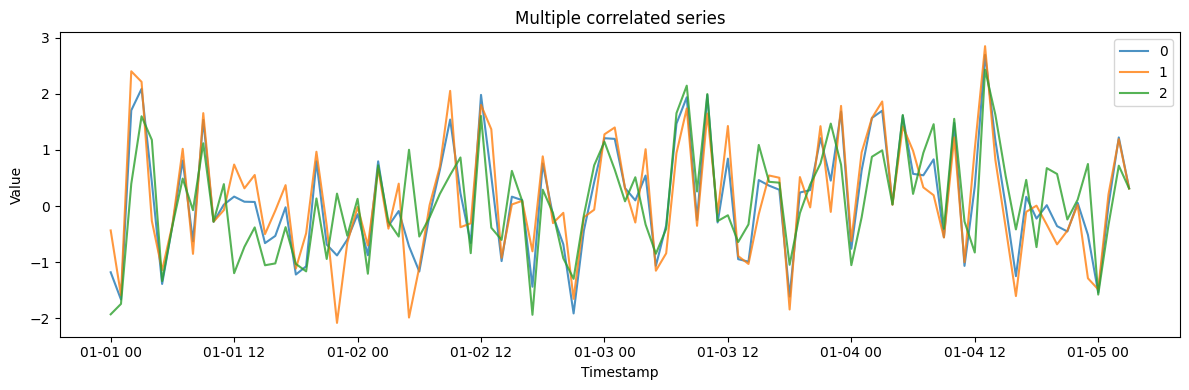

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_multi["unique_id"].unique().to_list():
    series = df_multi.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple correlated series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [VAR](var) — dependence that plays out *over time* (lead-lag), not just contemporaneously.
- [Multivariatize](../../capabilities/multivariatize) — turn any univariate generator into coupled channels.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::